In [9]:
pip install matplotlib

  Using cached matplotlib-3.7.5-cp38-cp38-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (9.2 MB)
  Using cached kiwisolver-1.4.7-cp38-cp38-manylinux_2_5_x86_64.manylinux1_x86_64.whl (1.2 MB)
  Using cached pyparsing-3.1.4-py3-none-any.whl (104 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     |████████████████████████████████| 4.7 MB 6.9 MB/s eta 0:00:01
  Using cached importlib_resources-6.4.5-py3-none-any.whl (36 kB)
  Using cached contourpy-1.1.1-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (301 kB)
  Using cached pillow-10.4.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.4 MB)
Note: you may need to restart the kernel to use updated packages.


In [25]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install statsmodels

  Using cached statsmodels-0.14.1-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (10.9 MB)
     |████████████████████████████████| 233 kB 8.2 MB/s eta 0:00:01
  Using cached scipy-1.10.1-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (34.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [49]:
df_regioes = pd.read_csv("datasets/consumo_energia_regioes_limpo.csv")
display(df_regioes.head())
display(df_regioes.info())

,ano,mes,regiao,tipo_consumo,consumo,data
0,2015,1,Centro-Oeste,Cativo,2414412,2015-01-01
1,2015,1,Centro-Oeste,Comercial,607356,2015-01-01
2,2015,1,Centro-Oeste,Industrial,677273,2015-01-01
3,2015,1,Centro-Oeste,Outros,583718,2015-01-01
4,2015,1,Centro-Oeste,Residencial,989503,2015-01-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ano           3240 non-null   int64 
 1   mes           3240 non-null   int64 
 2   regiao        3240 non-null   object
 3   tipo_consumo  3240 non-null   object
 4   consumo       3240 non-null   int64 
 5   data          3240 non-null   object
dtypes: int64(3), object(3)
memory usage: 152.0+ KB


None

Observação:
O conjunto de dados apresenta alta integridade, com ausência total de valores nulos (missing values). Isso elimina a necessidade de técnicas de imputação que poderiam comprometer a fidedignidade dos resultados.

Tratamento necessário para analisar os componentes da série temporal: converter a coluna "data" para o tipo datetime.

In [12]:
df_regioes['data'] = pd.to_datetime(df_regioes['data'])

In [14]:
#verificando se a conversão foi realizada
df_regioes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ano           3240 non-null   int64         
 1   mes           3240 non-null   int64         
 2   regiao        3240 non-null   object        
 3   tipo_consumo  3240 non-null   object        
 4   consumo       3240 non-null   int64         
 5   data          3240 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 152.0+ KB


Vamos definir a coluna **data** como índice.

In [15]:
df_regioes.set_index('data', inplace=True)

In [ ]:
# Criando um filtro para isolar a série que queremos analisar
filtro = (df_regioes['regiao'] == 'Nordeste') & (df_regioes['tipo_consumo'] == 'Residencial')
serie_nordeste_res = df_regioes[filtro]['consumo']


print(serie_nordeste_res.head())

data
2015-01-01    2302666
2015-02-01    2240786
2015-03-01    2213527
2015-04-01    2232375
2015-05-01    2218162
Name: consumo, dtype: int64


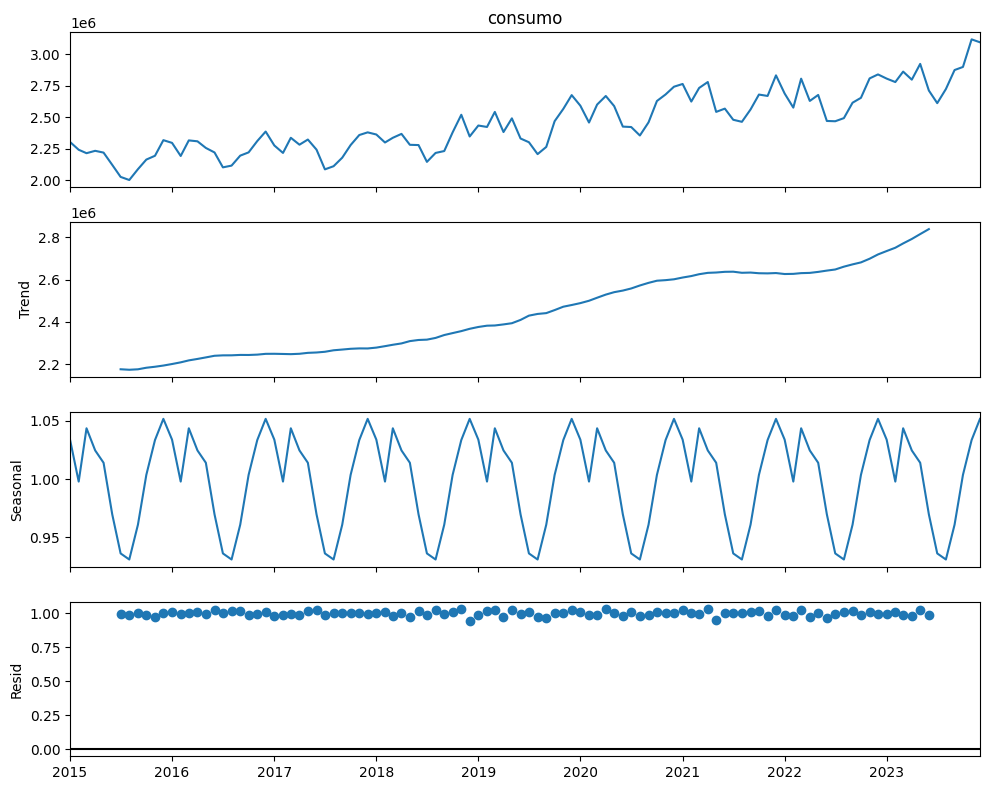

In [ ]:
# Realizando a decomposição
# model='multiplicative' 
resultado = seasonal_decompose(serie_nordeste_res, model='multiplicative')

# Plotando os quatro gráficos de uma vez
plt.rcParams.update({'figure.figsize': (10,8)})
resultado.plot()
plt.show()

In [23]:
filtro = (df_regioes['regiao'] == 'Sudeste') & (df_regioes['tipo_consumo'] == 'Residencial')
serie_sudeste_res = df_regioes[filtro]['consumo']

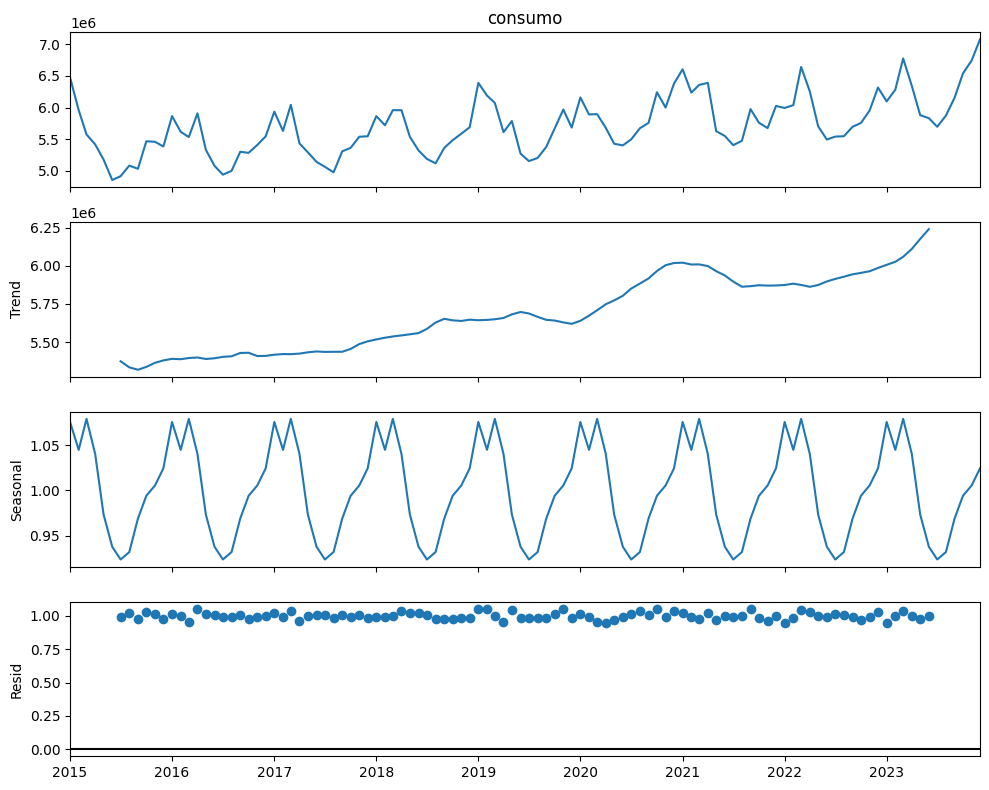

In [24]:
# Realizando a decomposição
# model='multiplicative' 
resultado = seasonal_decompose(serie_sudeste_res, model='multiplicative')

# Plotando os quatro gráficos de uma vez
plt.rcParams.update({'figure.figsize': (10,8)})
resultado.plot()
plt.show()

O gráfico de resíduos apresenta-se estabilizado em torno de 1.0, indicando que o modelo multiplicativo foi capaz de capturar a maior parte da variabilidade da série. Pequenas flutuações residuais observadas sugerem eventos estocásticos (como variações climáticas extremas ou mudanças tarifárias pontuais) que não seguem o padrão sazonal típico.

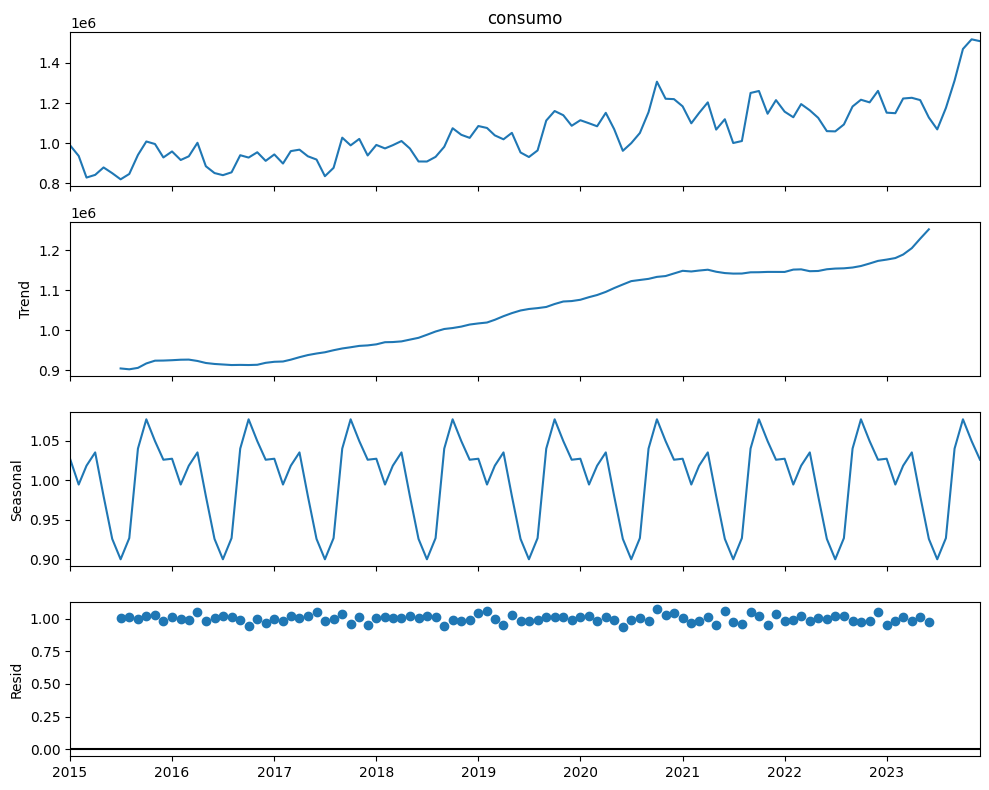

In [28]:
# Criando um filtro para isolar a série que queremos analisar
filtro = (df_regioes['regiao'] == 'Centro-Oeste') & (df_regioes['tipo_consumo'] == 'Residencial')
serie_centroOeste_res = df_regioes[filtro]['consumo']

# Realizando a decomposição
# model='multiplicative' 
resultado = seasonal_decompose(serie_centroOeste_res, model='multiplicative')

# Plotando os quatro gráficos de uma vez
plt.rcParams.update({'figure.figsize': (10,8)})
resultado.plot()
plt.show()

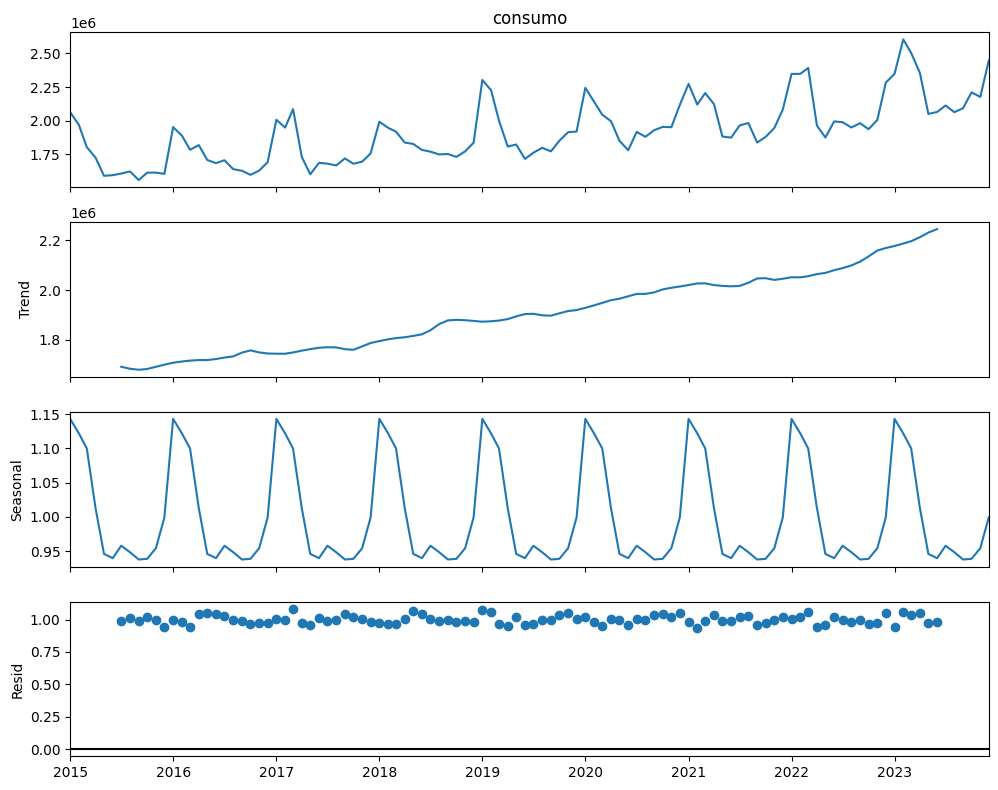

In [29]:
# Criando um filtro para isolar a série que queremos analisar
filtro = (df_regioes['regiao'] == 'Sul') & (df_regioes['tipo_consumo'] == 'Residencial')
serie_sul_res = df_regioes[filtro]['consumo']

# Realizando a decomposição
# model='multiplicative' 
resultado = seasonal_decompose(serie_sul_res, model='multiplicative')

# Plotando os quatro gráficos de uma vez
plt.rcParams.update({'figure.figsize': (10,8)})
resultado.plot()
plt.show()

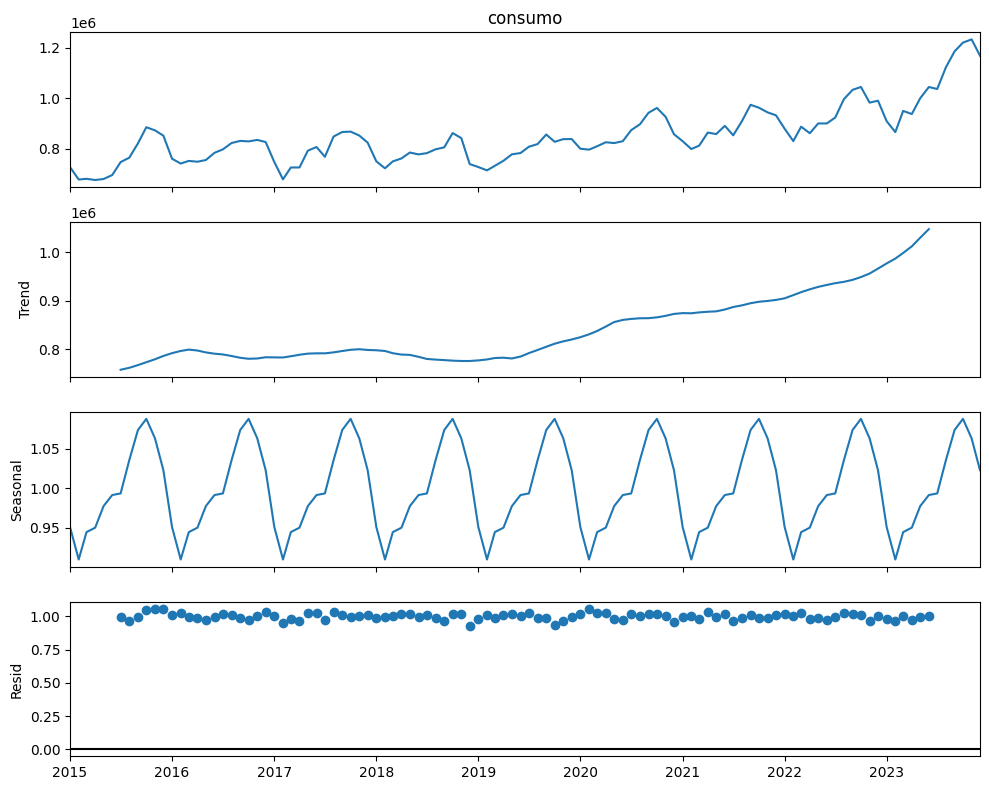

In [30]:
# Criando um filtro para isolar a série que queremos analisar
filtro = (df_regioes['regiao'] == 'Norte') & (df_regioes['tipo_consumo'] == 'Residencial')
serie_norte_res = df_regioes[filtro]['consumo']

# Realizando a decomposição
# model='multiplicative' 
resultado = seasonal_decompose(serie_norte_res, model='multiplicative')

# Plotando os quatro gráficos de uma vez
plt.rcParams.update({'figure.figsize': (10,8)})
resultado.plot()
plt.show()

### Análise mais aprofundada dos resíduos

In [36]:

regiao_alvo = 'Nordeste'
tipo_alvo = 'Residencial'


# Criamos a cópia para não mexer no original
df_regiao = df_regioes[(df_regioes['regiao'] == regiao_alvo) & (df_regioes['tipo_consumo'] == tipo_alvo)].copy()

# 2. SE 'data' ainda for uma coluna, a gente converte e joga pro índice
if 'data' in df_regiao.columns:
    df_regiao['data'] = pd.to_datetime(df_regiao['data'])
    df_regiao.set_index('data', inplace=True)
# 3. SE a data já for o índice, a gente só garante que está no formato datetime
else:
    df_regiao.index = pd.to_datetime(df_regiao.index)

# 4. Ordenar e definir a frequência mensal
df_regiao = df_regiao.sort_index()
df_regiao = df_regiao.asfreq('MS')

# 5. Selecionar o consumo (removendo nulos se o asfreq criou algum buraco)
serie_consumo = df_regiao['consumo'].dropna()

print(f"Pronto! Série do {regiao_alvo} carregada com {len(serie_consumo)} meses.")

Pronto! Série do Nordeste carregada com 108 meses.


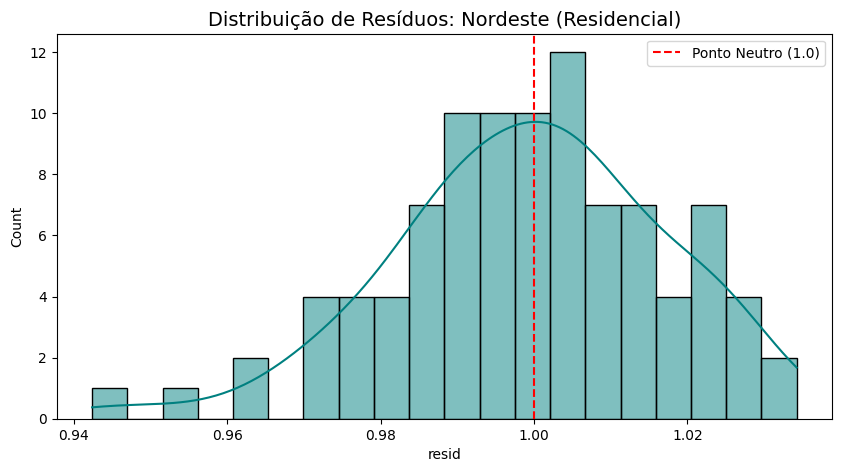

In [37]:
import seaborn as sns
# Realiza a decomposição
res = seasonal_decompose(serie_consumo, model='multiplicative')
residuos = res.resid.dropna()

# Plota o Histograma
plt.figure(figsize=(10, 5))
sns.histplot(residuos, kde=True, color='teal', bins=20)
plt.axvline(1.0, color='red', linestyle='--', label='Ponto Neutro (1.0)')

plt.title(f'Distribuição de Resíduos: {regiao_alvo} ({tipo_alvo})', fontsize=14)
plt.legend()
plt.show()

In [38]:
regiao_alvo = 'Sudeste'
tipo_alvo = 'Residencial'


# Criamos a cópia para não mexer no original
df_regiao = df_regioes[(df_regioes['regiao'] == regiao_alvo) & (df_regioes['tipo_consumo'] == tipo_alvo)].copy()

# 2. SE 'data' ainda for uma coluna, a gente converte e joga pro índice
if 'data' in df_regiao.columns:
    df_regiao['data'] = pd.to_datetime(df_regiao['data'])
    df_regiao.set_index('data', inplace=True)
# 3. SE a data já for o índice, a gente só garante que está no formato datetime
else:
    df_regiao.index = pd.to_datetime(df_regiao.index)

# 4. Ordenar e definir a frequência mensal
df_regiao = df_regiao.sort_index()
df_regiao = df_regiao.asfreq('MS')

# 5. Selecionar o consumo (removendo nulos se o asfreq criou algum buraco)
serie_consumo = df_regiao['consumo'].dropna()

print(f"Pronto! Série do {regiao_alvo} carregada com {len(serie_consumo)} meses.")

Pronto! Série do Sudeste carregada com 108 meses.


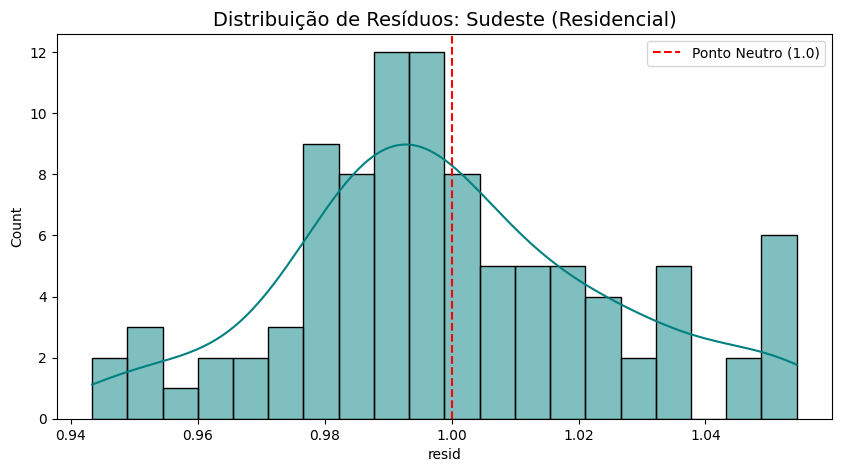

In [39]:
import seaborn as sns
# Realiza a decomposição
res = seasonal_decompose(serie_consumo, model='multiplicative')
residuos = res.resid.dropna()

# Plota o Histograma
plt.figure(figsize=(10, 5))
sns.histplot(residuos, kde=True, color='teal', bins=20)
plt.axvline(1.0, color='red', linestyle='--', label='Ponto Neutro (1.0)')

plt.title(f'Distribuição de Resíduos: {regiao_alvo} ({tipo_alvo})', fontsize=14)
plt.legend()
plt.show()

In [42]:
regiao_alvo = 'Sul'
tipo_alvo = 'Residencial'


# Criamos a cópia para não mexer no original
df_regiao = df_regioes[(df_regioes['regiao'] == regiao_alvo) & (df_regioes['tipo_consumo'] == tipo_alvo)].copy()

# 2. SE 'data' ainda for uma coluna, a gente converte e joga pro índice
if 'data' in df_regiao.columns:
    df_regiao['data'] = pd.to_datetime(df_regiao['data'])
    df_regiao.set_index('data', inplace=True)
# 3. SE a data já for o índice, a gente só garante que está no formato datetime
else:
    df_regiao.index = pd.to_datetime(df_regiao.index)

# 4. Ordenar e definir a frequência mensal
df_regiao = df_regiao.sort_index()
df_regiao = df_regiao.asfreq('MS')

# 5. Selecionar o consumo (removendo nulos se o asfreq criou algum buraco)
serie_consumo = df_regiao['consumo'].dropna()

print(f"Pronto! Série do {regiao_alvo} carregada com {len(serie_consumo)} meses.")

Pronto! Série do Sul carregada com 108 meses.


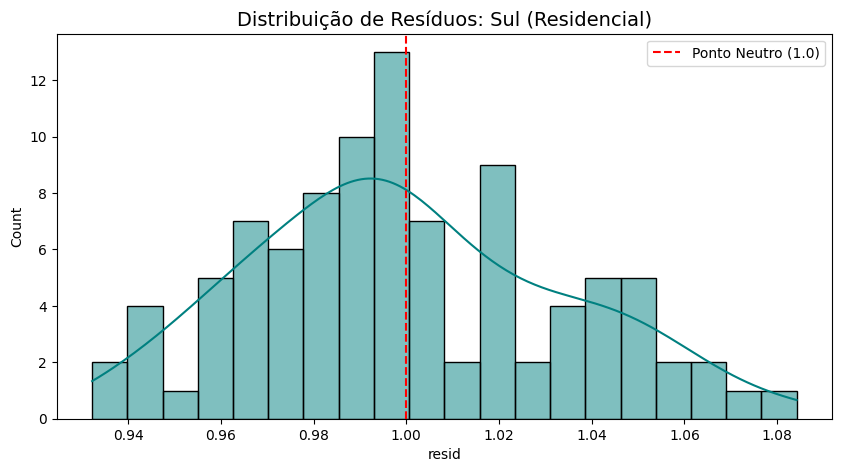

In [43]:
import seaborn as sns
# Realiza a decomposição
res = seasonal_decompose(serie_consumo, model='multiplicative')
residuos = res.resid.dropna()

# Plota o Histograma
plt.figure(figsize=(10, 5))
sns.histplot(residuos, kde=True, color='teal', bins=20)
plt.axvline(1.0, color='red', linestyle='--', label='Ponto Neutro (1.0)')

plt.title(f'Distribuição de Resíduos: {regiao_alvo} ({tipo_alvo})', fontsize=14)
plt.legend()
plt.show()

In [44]:
regiao_alvo = 'Norte'
tipo_alvo = 'Residencial'


# Criamos a cópia para não mexer no original
df_regiao = df_regioes[(df_regioes['regiao'] == regiao_alvo) & (df_regioes['tipo_consumo'] == tipo_alvo)].copy()

# 2. SE 'data' ainda for uma coluna, a gente converte e joga pro índice
if 'data' in df_regiao.columns:
    df_regiao['data'] = pd.to_datetime(df_regiao['data'])
    df_regiao.set_index('data', inplace=True)
# 3. SE a data já for o índice, a gente só garante que está no formato datetime
else:
    df_regiao.index = pd.to_datetime(df_regiao.index)

# 4. Ordenar e definir a frequência mensal
df_regiao = df_regiao.sort_index()
df_regiao = df_regiao.asfreq('MS')

# 5. Selecionar o consumo (removendo nulos se o asfreq criou algum buraco)
serie_consumo = df_regiao['consumo'].dropna()

print(f"Pronto! Série do {regiao_alvo} carregada com {len(serie_consumo)} meses.")

Pronto! Série do Norte carregada com 108 meses.


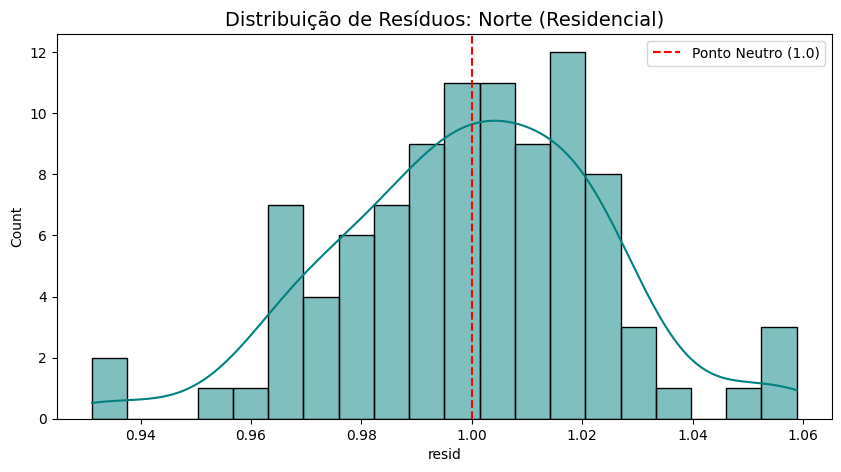

In [45]:
import seaborn as sns
# Realiza a decomposição
res = seasonal_decompose(serie_consumo, model='multiplicative')
residuos = res.resid.dropna()

# Plota o Histograma
plt.figure(figsize=(10, 5))
sns.histplot(residuos, kde=True, color='teal', bins=20)
plt.axvline(1.0, color='red', linestyle='--', label='Ponto Neutro (1.0)')

plt.title(f'Distribuição de Resíduos: {regiao_alvo} ({tipo_alvo})', fontsize=14)
plt.legend()
plt.show()

In [46]:
regiao_alvo = 'Centro-Oeste'
tipo_alvo = 'Residencial'


# Criamos a cópia para não mexer no original
df_regiao = df_regioes[(df_regioes['regiao'] == regiao_alvo) & (df_regioes['tipo_consumo'] == tipo_alvo)].copy()

# 2. SE 'data' ainda for uma coluna, a gente converte e joga pro índice
if 'data' in df_regiao.columns:
    df_regiao['data'] = pd.to_datetime(df_regiao['data'])
    df_regiao.set_index('data', inplace=True)
# 3. SE a data já for o índice, a gente só garante que está no formato datetime
else:
    df_regiao.index = pd.to_datetime(df_regiao.index)

# 4. Ordenar e definir a frequência mensal
df_regiao = df_regiao.sort_index()
df_regiao = df_regiao.asfreq('MS')

# 5. Selecionar o consumo (removendo nulos se o asfreq criou algum buraco)
serie_consumo = df_regiao['consumo'].dropna()

print(f"Pronto! Série do {regiao_alvo} carregada com {len(serie_consumo)} meses.")

Pronto! Série do Centro-Oeste carregada com 108 meses.


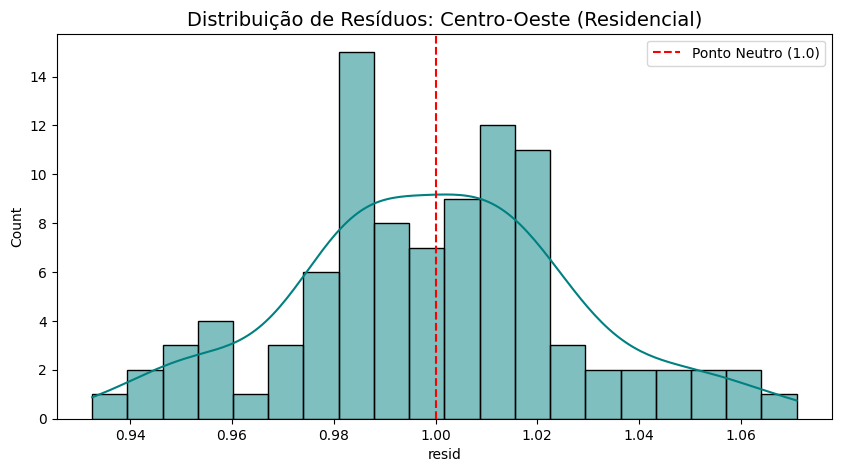

In [47]:
import seaborn as sns
# Realiza a decomposição
res = seasonal_decompose(serie_consumo, model='multiplicative')
residuos = res.resid.dropna()

# Plota o Histograma
plt.figure(figsize=(10, 5))
sns.histplot(residuos, kde=True, color='teal', bins=20)
plt.axvline(1.0, color='red', linestyle='--', label='Ponto Neutro (1.0)')

plt.title(f'Distribuição de Resíduos: {regiao_alvo} ({tipo_alvo})', fontsize=14)
plt.legend()
plt.show()